<a href="https://colab.research.google.com/github/Geddada-Lavanya/genai-nlp-cv-workshop-hands-on-/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Image Classification using Pre_trained Model
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

# Download a sample image to ensure the file exists
img_path = tf.keras.utils.get_file('dog.jpg', 'http://images.cocodataset.org/val2017/000000039769.jpg') # A common dog image from COCO dataset

model = MobileNetV2(weights='imagenet')
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
preds = model.predict(x)
print("Prediction:", decode_predictions(preds, top=3)[0])

173131/173131 ━━━━━━━━━━━━━━━━━━━━ 1s 4us/step
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Prediction: [('n02123045', 'tabby', np.float32(0.4775044)), ('n02123159', 'tiger_cat', np.float32(0.28268626)), ('n02124075', 'Egyptian_cat', np.float32(0.13289088))]


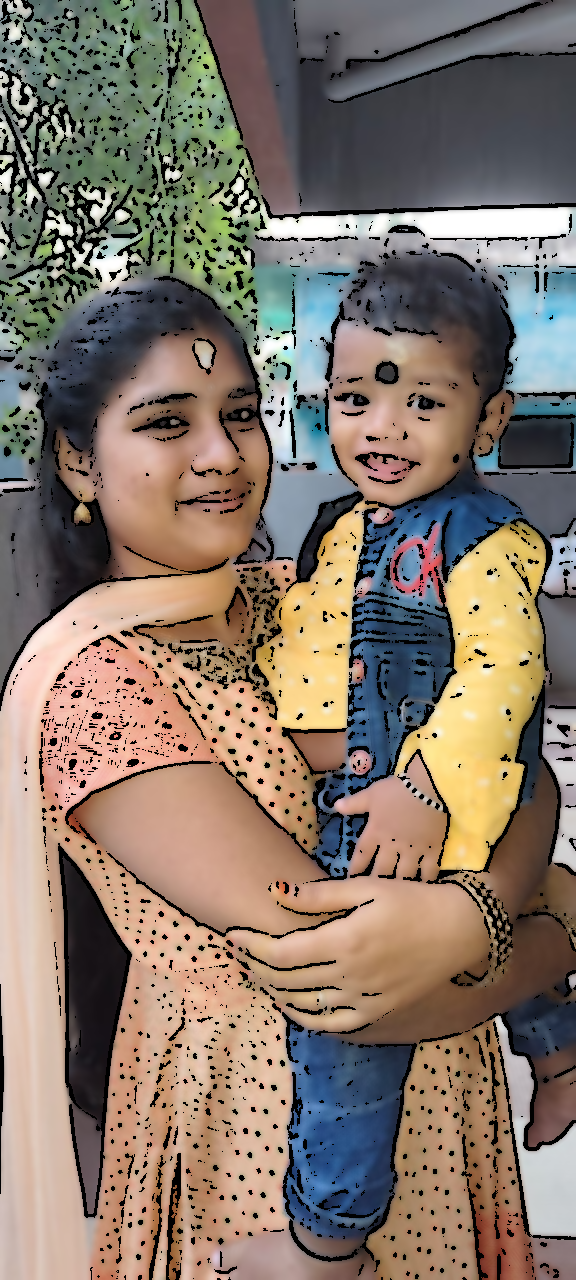

In [ ]:
#Image Catoonifier

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("a.jpg")

# Convert to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur
gray_blur = cv2.medianBlur(gray, 5)

# Edge detection
edges = cv2.adaptiveThreshold(gray_blur, 255,
                              cv2.ADAPTIVE_THRESH_MEAN_C,
                              cv2.THRESH_BINARY, 9, 9)

# Cartoon effect
color = cv2.bilateralFilter(img, 9, 250, 250)
cartoon = cv2.bitwise_and(color, color, mask=edges)

cv2_imshow(cartoon)
cv2.waitKey(0)
cv2.destroyAllWindows()


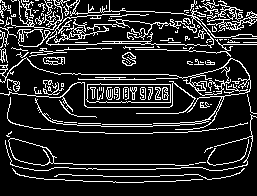

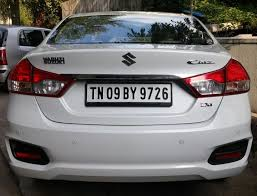

In [ ]:
#Number Plate Detection

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("car.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reduce noise
gray = cv2.bilateralFilter(gray, 11, 17, 17)

# Edge detection
edges = cv2.Canny(gray, 30, 200)

# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate = None

for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.018 * cv2.arcLength(cnt, True), True)

    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(cnt)
        plate = img[y:y+h, x:x+w]
        cv2_imshow(plate)
        break

cv2_imshow(edges)
cv2_imshow(img)

cv2.waitKey(0)
cv2.destroyAllWindows()

haarcascade_frontalface_default.xml downloaded successfully.


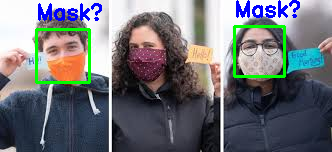

In [ ]:
#Face mask Detection

import cv2
from google.colab.patches import cv2_imshow
import requests

# Download the haarcascade_frontalface_default.xml if not present
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_filename = "haarcascade_frontalface_default.xml"

# Check if the cascade file exists, if not, download it
try:
    with open(cascade_filename, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"Downloading {cascade_filename}...")
    response = requests.get(cascade_url)
    if response.status_code == 200:
        with open(cascade_filename, 'wb') as f:
            f.write(response.content)
        print(f"{cascade_filename} downloaded successfully.")
    else:
        print(f"Error: Could not download {cascade_filename}. Status code: {response.status_code}")

face_cascade = cv2.CascadeClassifier(cascade_filename)

# Check if the cascade classifier loaded successfully
if face_cascade.empty():
    print("Error: Could not load face cascade classifier. Ensure the XML file is correct and accessible.")
else:
    img_path = "facee.jpg"
    img = cv2.imread(img_path)

    # If 'facee.jpg' is not found, download a sample image for demonstration
    if img is None:
        print(f"Warning: Image '{img_path}' not found. Downloading a sample image for demonstration.")
        sample_face_url = "https://cdn.pixabay.com/photo/2016/11/29/05/45/astronomy-1867616_1280.jpg" # A generic image with faces
        response = requests.get(sample_face_url)
        if response.status_code == 200:
            with open("sample_face.jpg", "wb") as f:
                f.write(response.content)
            img = cv2.imread("sample_face.jpg")
            img_path = "sample_face.jpg"
        else:
            print("Error: Could not download sample image. Please ensure an image file is available.")

    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        if len(faces) == 0:
            print("No faces detected in the image.")

        for (x,y,w,h) in faces:
            cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
            cv2.putText(img, "Mask?", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

        cv2_imshow(img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Error: No image loaded for face detection.")

Saving flower.webp to flower.webp


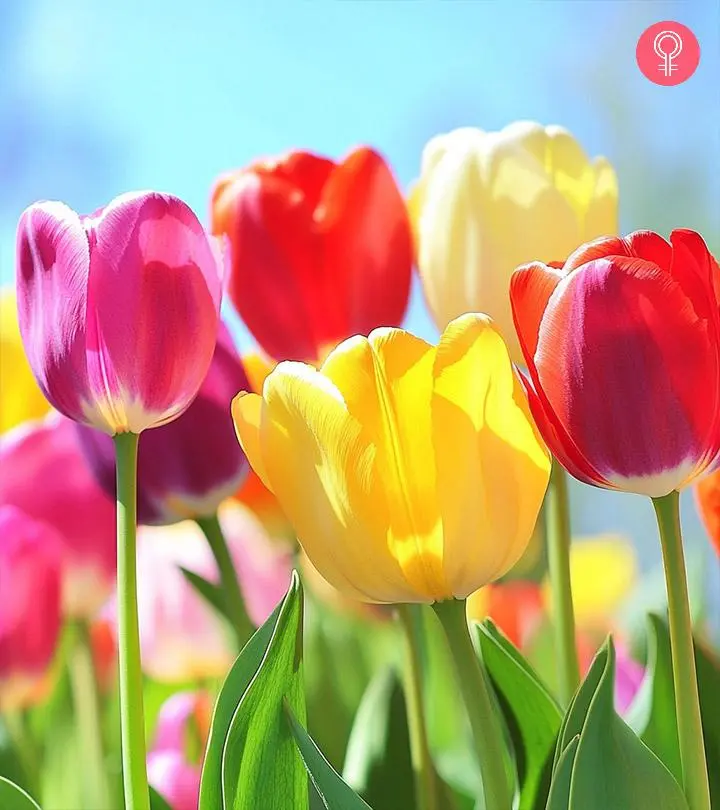

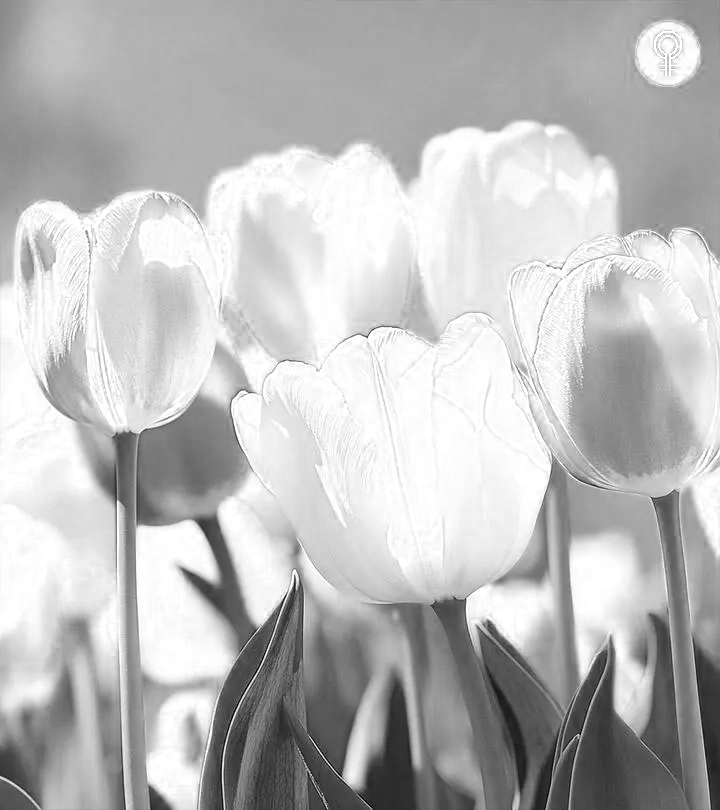

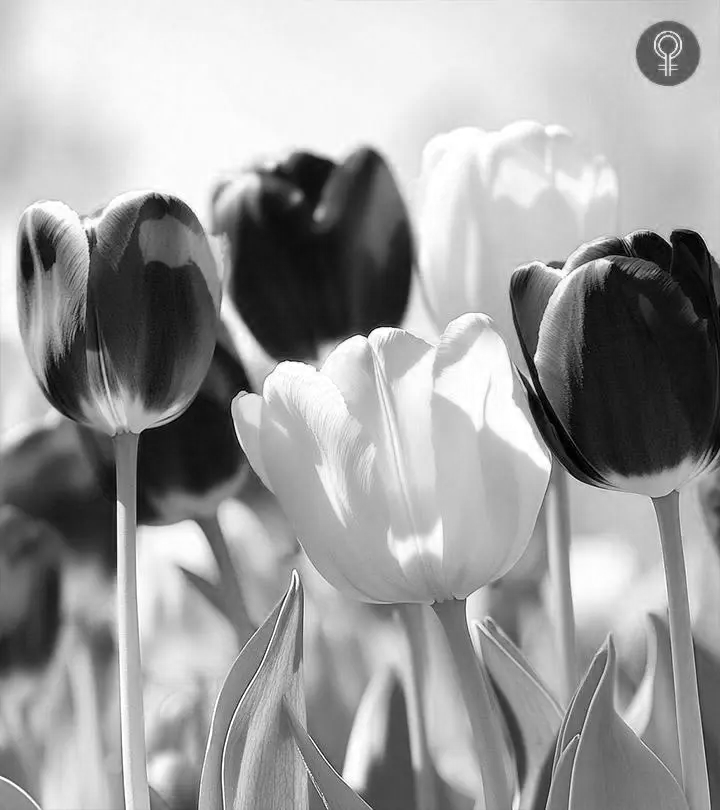

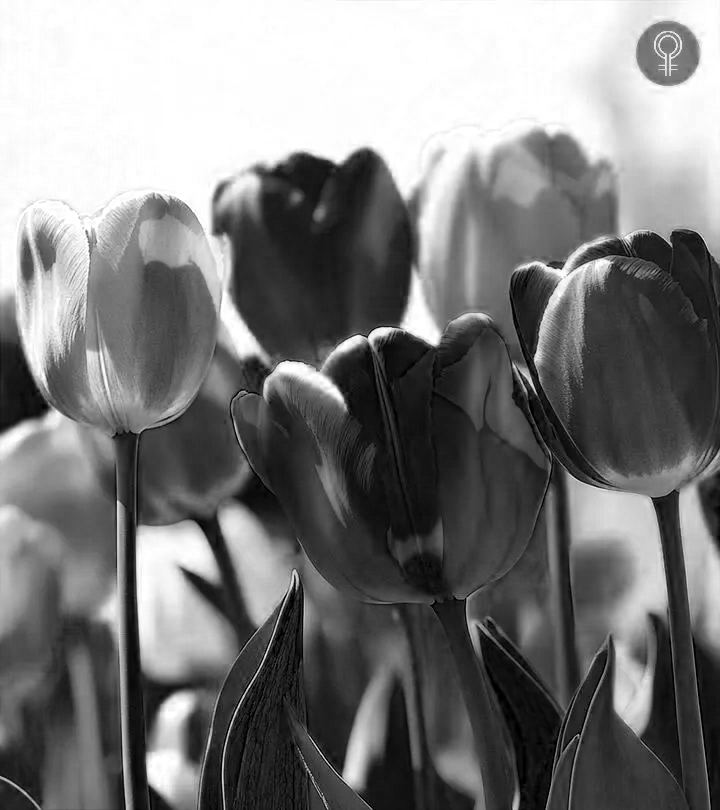

In [ ]:
#Color Channel Separation (RGB Split)

import cv2
from google.colab.patches import cv2_imshow

# Upload image first
from google.colab import files
uploaded = files.upload()

# Read image
img = cv2.imread("flower.webp")

# Split channels
B, G, R = cv2.split(img)

# Show outputs
cv2_imshow(img)
cv2_imshow(R)
cv2_imshow(G)
cv2_imshow(B)